**1.Import Data and Libraries**

In [ ]:
import pandas as pd
import numpy as np

**2.Load & Basic Understanding**

In [ ]:
# Reading in data
data=pd.read_excel('../data/TeleCom_Data-1.xlsx')

# Display the first few rows of the dataset
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# Display the last few rows of the dataset
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41175,29,unemployed,single,basic.4y,no,yes,no,cellular,nov,fri,...,1,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,no
41176,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41177,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41178,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41179,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
#Shape of dataset
print("Shape of dataset:", data.shape)

#Column names
print("Columns:", data.columns.tolist())

Shape of dataset: (41180, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [ ]:
#Dataset Info
print("Data info:")
data.info()


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41180 entries, 0 to 41179
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41180 non-null  int64  
 1   job             41180 non-null  object 
 2   marital         41180 non-null  object 
 3   education       41180 non-null  object 
 4   default         41180 non-null  object 
 5   housing         41180 non-null  object 
 6   loan            41180 non-null  object 
 7   contact         41180 non-null  object 
 8   month           41180 non-null  object 
 9   day_of_week     41180 non-null  object 
 10  duration        41180 non-null  int64  
 11  campaign        41180 non-null  int64  
 12  pdays           41180 non-null  int64  
 13  previous        41180 non-null  int64  
 14  poutcome        41180 non-null  object 
 15  emp.var.rate    41180 non-null  float64
 16  cons.price.idx  41180 non-null  float64
 17  cons.conf.idx   4118

In [ ]:
# Rename column 'y' to 'subscribed'
data = data.rename(columns={'y': 'subscribed'})

# Convert 'yes' -> 1, 'no' -> 0 while safely handling NaNs
data['subscribed'] = data['subscribed'].map({'yes': 1, 'no': 0})

# If you want to replace NaN with 0 (optional, depending on your case)
data['subscribed'] = data['subscribed'].fillna(0).astype(int)

# Check the result
print(data['subscribed'].value_counts(dropna=False))


subscribed
0    36542
1     4638
Name: count, dtype: int64


In [ ]:
# Show data types
print("Data types of each column:")
print(data.dtypes)

print("Number of numeric columns:", len(data.select_dtypes(include=['int64', 'float64']).columns))
print("Number of categorical columns:", len(data.select_dtypes(include=['object']).columns))

Data types of each column:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
subscribed          int64
dtype: object
Number of numeric columns: 11
Number of categorical columns: 10


In [ ]:
#Summary statistics of the dataset
data.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
count,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000
mean,40.021710,258.280427,2.567800,962.516707,0.172705,0.081901,93.575508,-40.501999,3.621422,5167.053344,0.112627
std,10.419593,259.299856,2.770225,186.809028,0.493719,1.571037,0.578762,4.627358,1.734385,72.230334,0.316141
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [ ]:
#Summary statistics for numeric variables
print("Numeric summary:")
data.describe().T

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,41180.0,40.021710,10.419593,17.000,32.000,38.000,47.000,98.000
duration,41180.0,258.280427,259.299856,0.000,102.000,180.000,319.000,4918.000
campaign,41180.0,2.567800,2.770225,1.000,1.000,2.000,3.000,56.000
pdays,41180.0,962.516707,186.809028,0.000,999.000,999.000,999.000,999.000
previous,41180.0,0.172705,0.493719,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41180.0,0.081901,1.571037,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41180.0,93.575508,0.578762,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41180.0,-40.501999,4.627358,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41180.0,3.621422,1.734385,0.634,1.344,4.857,4.961,5.045
nr.employed,41180.0,5167.053344,72.230334,4963.600,5099.100,5191.000,5228.100,5228.100


In [ ]:
#Unique values per categorical column (first 10 shown)
print("Unique values in categorical columns:")
for col in data.select_dtypes(include="object").columns:
    print(f"{col}: {data[col].unique()[:10]}")  # show only first 10 uniques

Unique values in categorical columns:
job: ['admin.' 'services' 'blue-collar' 'technician' 'housemaid' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown']
marital: ['married' 'single' 'divorced' 'unknown']
education: ['basic.6y' 'high.school' 'basic.9y' 'professional.course' 'unknown'
 'basic.4y' 'university.degree' 'illiterate']
default: ['no' 'unknown' 'yes']
housing: ['no' 'yes' 'unknown']
loan: ['no' 'yes' 'unknown']
contact: ['telephone' 'cellular']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week: ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome: ['nonexistent' 'failure' 'success']


In [ ]:
#Target variable distribution (class balance)
print("Target variable distribution (absolute):", data['subscribed'].value_counts())
print("Target variable distribution (percentage):", data['subscribed'].value_counts(normalize=True) * 100)

Target variable distribution (absolute): subscribed
0    36542
1     4638
Name: count, dtype: int64
Target variable distribution (percentage): subscribed
0    88.737251
1    11.262749
Name: proportion, dtype: float64


In [ ]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
if 'month' in data.columns:
    data['month'] = pd.Categorical(data['month'], categories=month_order, ordered=True)


**3.Data Cleaning and Preperation**

In [ ]:
# Check for duplicate rows

# Count total duplicates (entire row repeated)
duplicates_count = data.duplicated().sum()
print("Total duplicate rows:", duplicates_count)

# Show duplicate rows (if any)
if duplicates_count > 0:
    print("Duplicate rows:")
    print(data[data.duplicated()])
else:
    print("No duplicate rows found.")


Total duplicate rows: 12
Duplicate rows:
       age          job   marital            education  default housing loan  \
1262    39  blue-collar   married             basic.6y       no      no   no   
12257   36      retired   married              unknown       no      no   no   
14230   27   technician    single  professional.course       no      no   no   
16952   47   technician  divorced          high.school       no     yes   no   
18461   32   technician    single  professional.course       no     yes   no   
20212   55     services   married          high.school  unknown      no   no   
20530   41   technician   married  professional.course       no     yes   no   
25213   39       admin.   married    university.degree       no      no   no   
28473   24     services    single          high.school       no     yes   no   
32512   35       admin.   married    university.degree       no     yes   no   
36947   45       admin.   married    university.degree       no      no   no   

In [ ]:
# Remove duplicate rows
data = data.drop_duplicates()

print("New shape after dropping duplicates:", data.shape)


New shape after dropping duplicates: (41168, 21)


In [ ]:
#Check for missing values
print("Missing values:", data.isnull().sum())

Missing values: age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
subscribed        0
dtype: int64


In [ ]:
# Replace 'unknown' with NaN in all columns
data = data.replace("unknown", np.nan)

# Re-check missing values
print("Missing values after replacement:\n", data.isnull().sum())

Missing values after replacement:
 age                  0
job                330
marital             80
education         1730
default           8595
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
subscribed           0
dtype: int64


In [ ]:
# Drop unnecessary columns
cols_to_drop = ["default", "day_of_week", "pdays", "emp.var.rate", "nr.employed"]
data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

print("New shape of dataset:", data.shape)
print("Remaining columns:", data.columns.tolist())

# Impute categorical variables with mode
for col in ["job", "marital", "education", "housing", "loan"]:
    data[col] = data[col].fillna(data[col].mode()[0])

# Check again
print("Missing values after handling:", data.isnull().sum())

New shape of dataset: (41168, 16)
Remaining columns: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'duration', 'campaign', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'subscribed']
Missing values after handling: age               0
job               0
marital           0
education         0
housing           0
loan              0
contact           0
month             0
duration          0
campaign          0
previous          0
poutcome          0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
subscribed        0
dtype: int64


**3.Exploratory Data Analysis (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Descriptive Statistics
data.describe()

,age,duration,campaign,previous,cons.price.idx,cons.conf.idx,euribor3m,subscribed
count,41168.000000,41168.000000,41168.000000,41168.000000,41168.000000,41168.000000,41168.000000,41168.000000
mean,40.021449,258.311237,2.568087,0.172756,93.575563,-40.502261,3.621425,0.112636
std,10.419022,259.325938,2.770530,0.493782,0.578761,4.627020,1.734375,0.316151
min,17.000000,0.000000,1.000000,0.000000,92.201000,-50.800000,0.634000,0.000000
25%,32.000000,102.000000,1.000000,0.000000,93.075000,-42.700000,1.344000,0.000000
50%,38.000000,180.000000,2.000000,0.000000,93.749000,-41.800000,4.857000,0.000000
75%,47.000000,319.000000,3.000000,0.000000,93.994000,-36.400000,4.961000,0.000000
max,98.000000,4918.000000,56.000000,7.000000,94.767000,-26.900000,5.045000,1.000000


/tmp/ipython-input-330282330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="subscribed", data=data, palette="Set2")


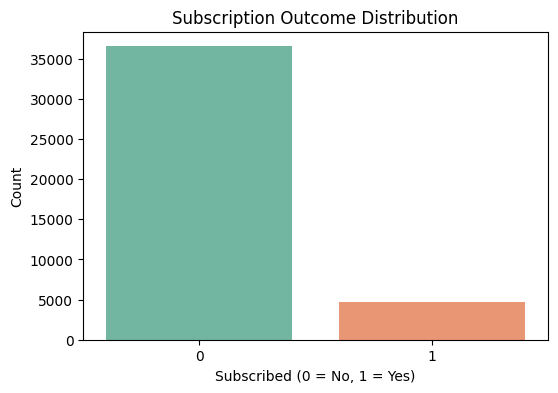

Subscription Rate (%):
subscribed
0    88.736397
1    11.263603
Name: proportion, dtype: float64


In [ ]:
# Distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x="subscribed", data=data, palette="Set2")
plt.title("Subscription Outcome Distribution")
plt.xlabel("Subscribed (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Percentage values
subscription_rate = data["subscribed"].value_counts(normalize=True) * 100
print("Subscription Rate (%):")
print(subscription_rate)


In [ ]:
numeric_cols = ["age", "campaign", "previous"]
categorical_cols = ["job", "marital", "education", "housing", "loan", "contact", "month", "poutcome"]

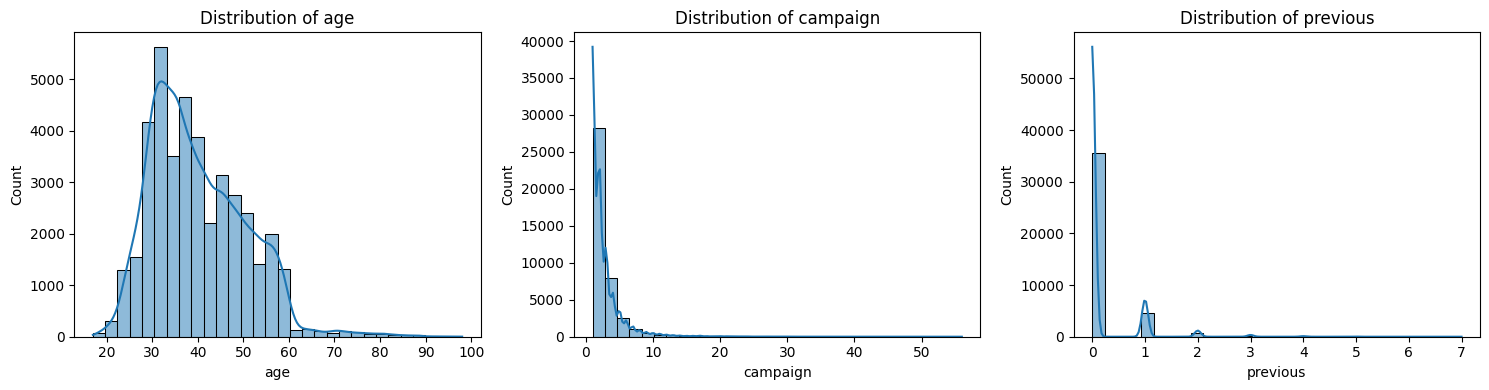

In [ ]:
# Univariate: Numeric
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


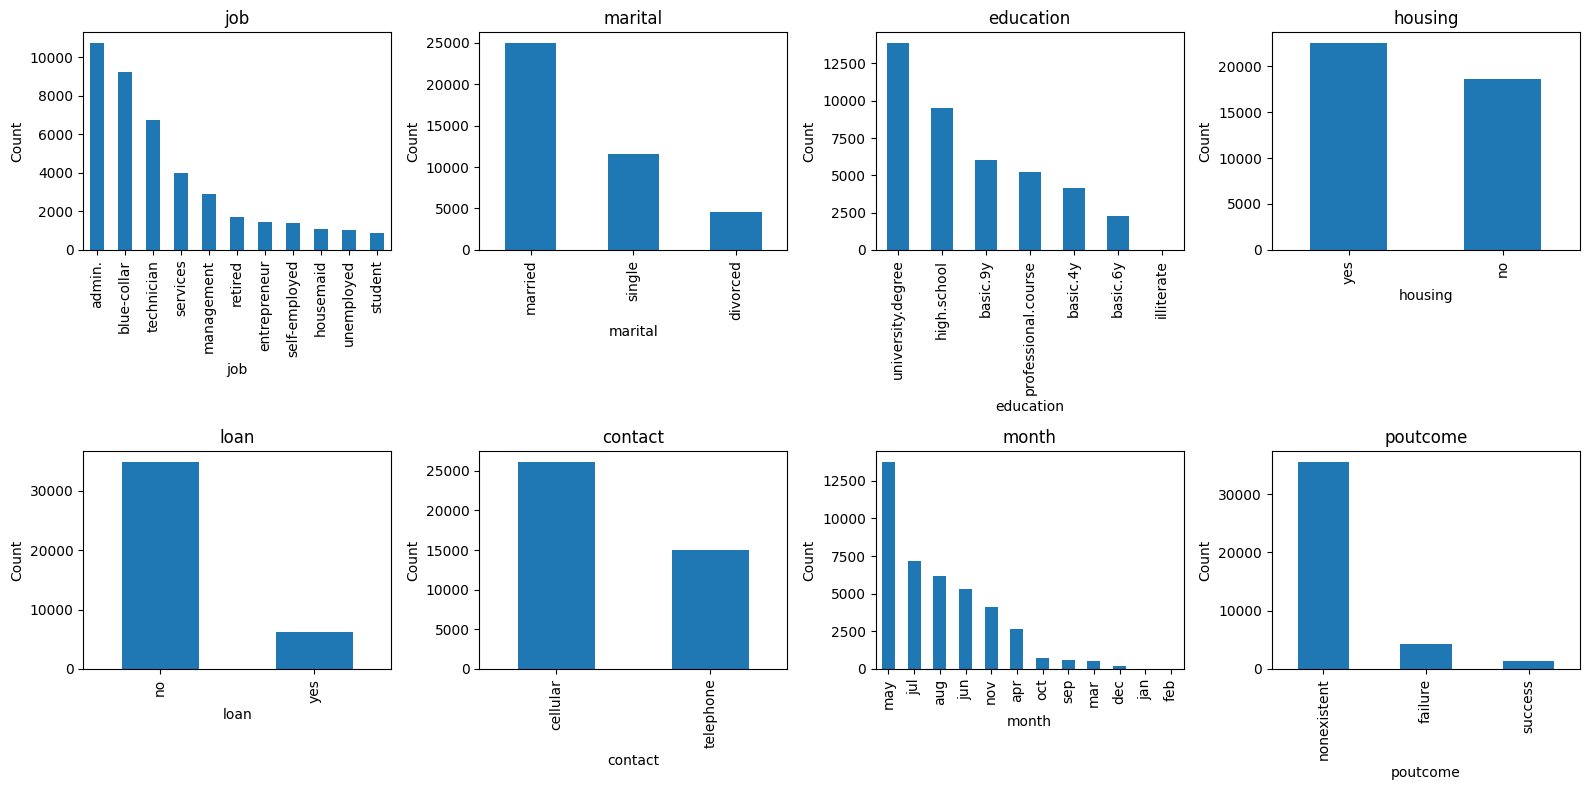

In [ ]:
# Univariate: Categorical
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    data[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

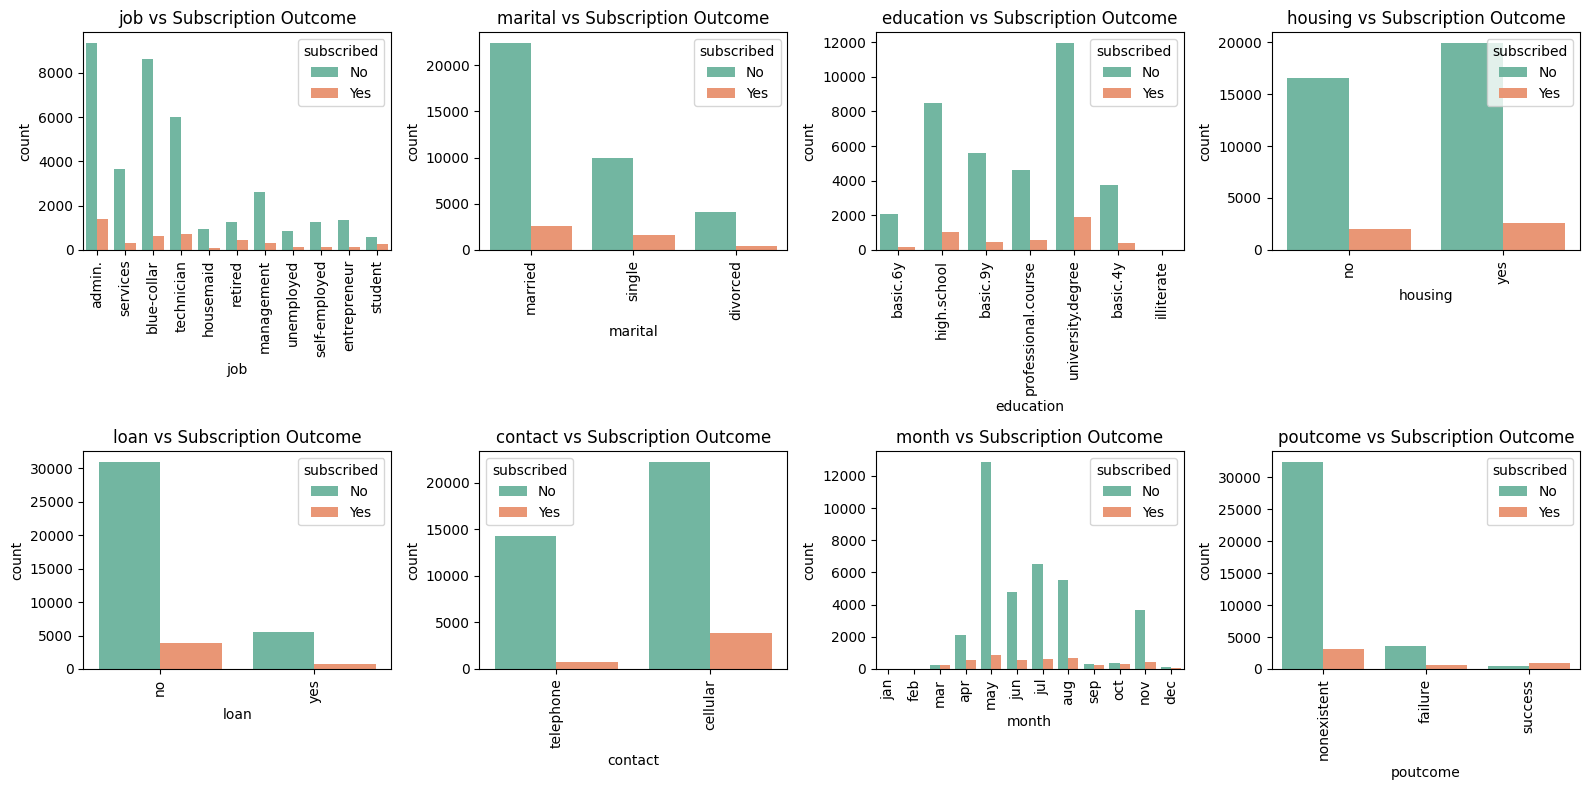

In [ ]:
data['subscribed'] = data['subscribed'].map({0: 'No', 1: 'Yes'})
# Bivariate: Categorical vs Target
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue="subscribed", data=data, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Subscription Outcome")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()



/tmp/ipython-input-806589766.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-806589766.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-806589766.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


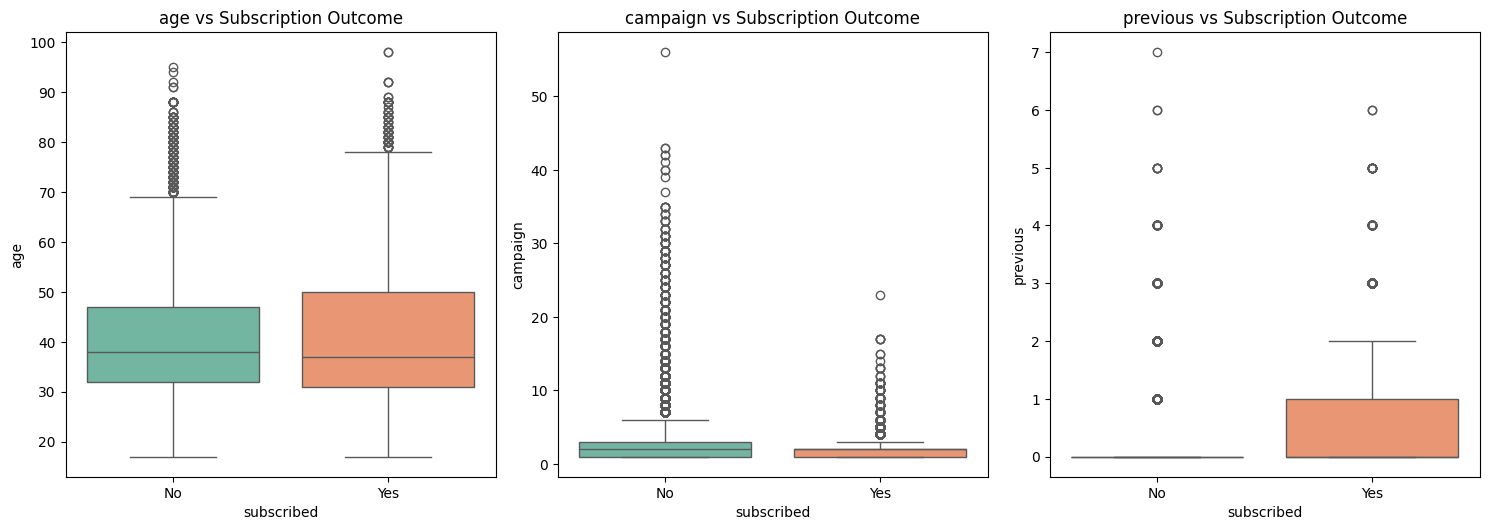

In [ ]:
#Bivariate: Numeric vs Target (Boxplots)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))  # adjust grid based on your numeric columns
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x="subscribed",
        y=col,
        data=data,
        ax=axes[i],
        palette="Set2"
    )
    axes[i].set_title(f"{col} vs Subscription Outcome")

# Remove empty subplots (if numeric_cols < grid size)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
# Convert 'subscribed' column to numeric (Yes=1, No=0)
data['subscribed'] = data['subscribed'].map({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})


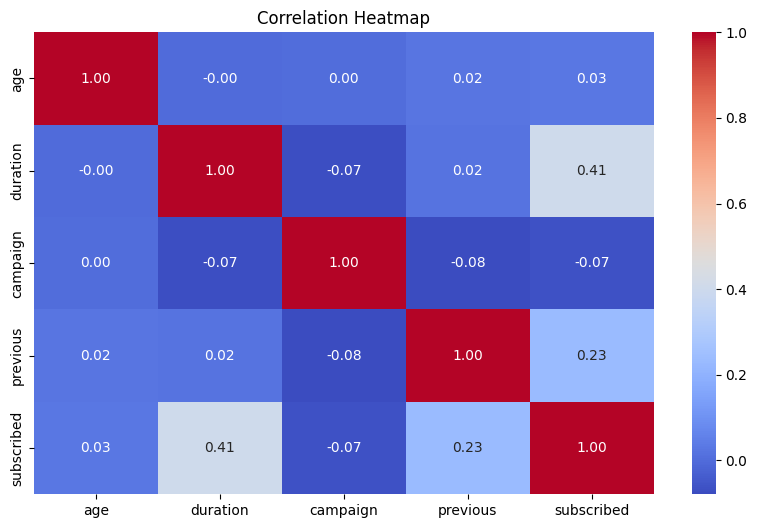

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
corr = data[['age','duration','campaign','previous','subscribed']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()




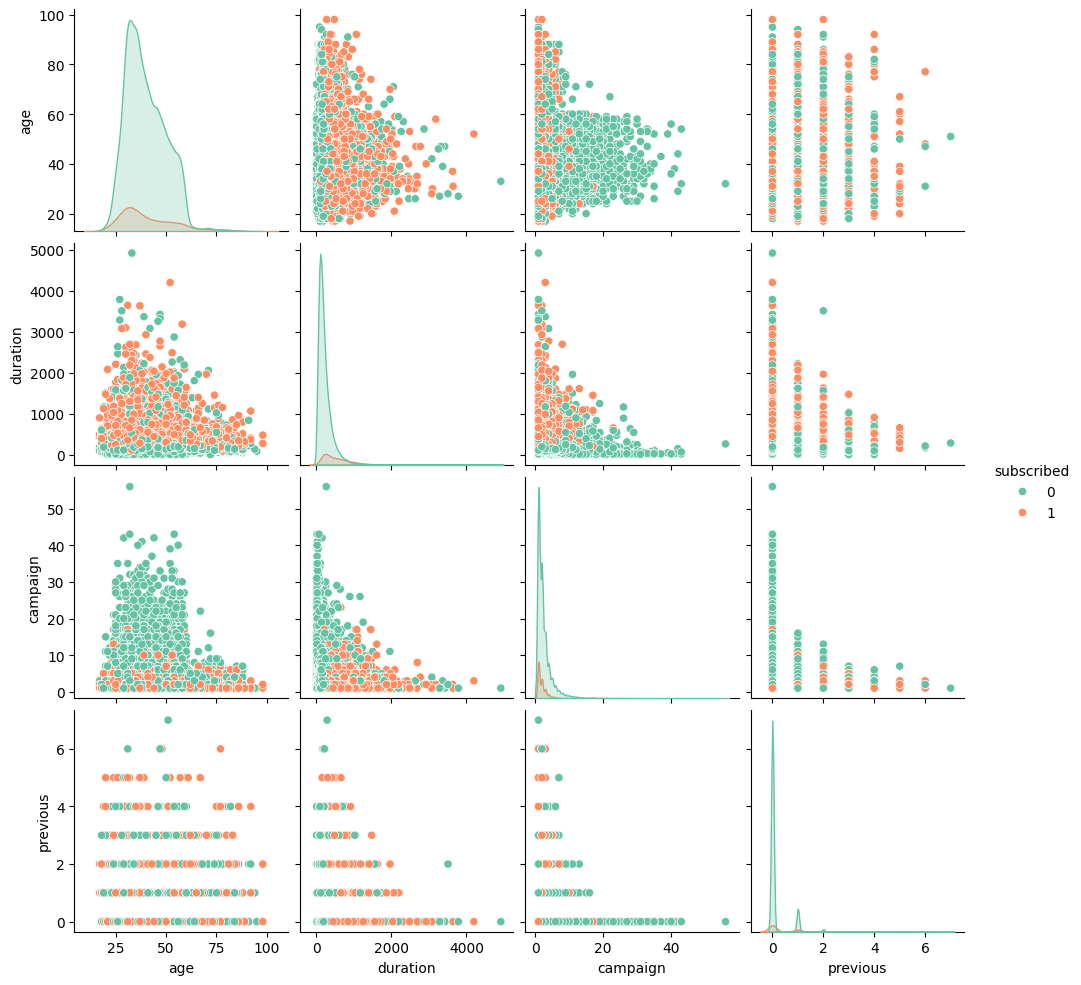

In [ ]:
#Pairplot for selected variables
sns.pairplot(data[['age','duration','campaign','previous','subscribed']],
             hue="subscribed", palette="Set2")
plt.show()



Cramer's V (strength of association) and Chi-square p-values:
    variable  cramers_v        p_value
0   poutcome   0.320006   0.000000e+00
1      month   0.274179   0.000000e+00
2        job   0.151833  1.246567e-199
3    contact   0.144522  3.208916e-189
4  education   0.067117   1.253338e-38
5    marital   0.053848   4.421829e-27
6    housing   0.009942   2.435078e-02
7       loan   0.000000   3.815698e-01


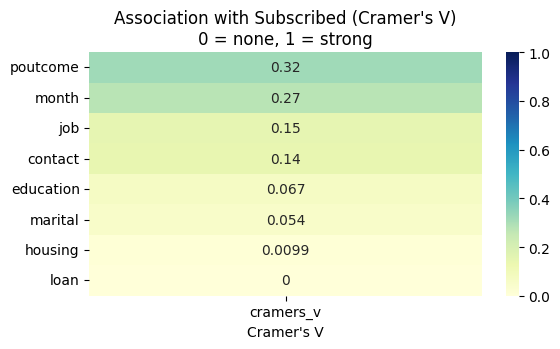

In [ ]:

from scipy.stats import chi2_contingency
# Fill missing categories with a label so they’re included in the test
for c in categorical_cols:
    data[c] = data[c].astype('object').fillna('Missing')

# --- Cramer's V with bias correction (for categorical vs categorical) ---
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    # bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

#Compute Cramer's V and p-values for each categorical feature vs subscribed ---
rows = []
for c in categorical_cols:
    valid = data[['subscribed', c]].dropna()
    cv = cramers_v(valid[c], valid['subscribed'])
    pval = chi2_contingency(pd.crosstab(valid[c], valid['subscribed']))[1]
    rows.append((c, cv, pval))

cv_df = (pd.DataFrame(rows, columns=['variable','cramers_v','p_value'])
           .sort_values('cramers_v', ascending=False)
           .reset_index(drop=True))

print("\nCramer's V (strength of association) and Chi-square p-values:")
print(cv_df)

# (categorical association with subscribed)
plt.figure(figsize=(6, max(3, 0.45*len(cv_df))))
sns.heatmap(cv_df[['cramers_v']].set_index(cv_df['variable']),
            annot=True, vmin=0, vmax=1, cmap='YlGnBu')
plt.title("Association with Subscribed (Cramer's V)\n0 = none, 1 = strong")
plt.xlabel("Cramer's V"); plt.ylabel("")
plt.tight_layout(); plt.show()



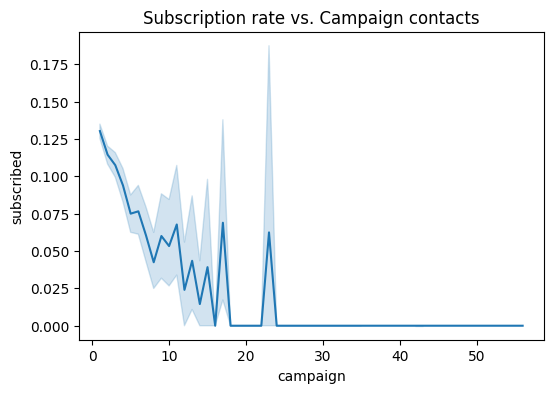

In [ ]:
# --- 4. Campaign effect ---
plt.figure(figsize=(6,4))
sns.lineplot(x="campaign", y="subscribed", data=data, estimator=lambda x: sum(x)/len(x))
plt.title("Subscription rate vs. Campaign contacts")
plt.show()

In [ ]:
# --- Cross tabulation for categorical variables with labels ---
# Map 0 → "No", 1 → "Yes"
data['subscribed_label'] = data['subscribed'].map({0: "No", 1: "Yes"})

for col in ['job','marital','education','contact','month']:
    ctab = pd.crosstab(data[col], data['subscribed_label'], normalize='index') * 100
    print(f"\nSubscription rate by {col}:\n")
    print(ctab.round(2))



Subscription rate by job:

subscribed_label     No    Yes
job                           
admin.            87.09  12.91
blue-collar       93.10   6.90
entrepreneur      91.48   8.52
housemaid         89.99  10.01
management        88.78  11.22
retired           74.77  25.23
self-employed     89.51  10.49
services          91.85   8.15
student           68.57  31.43
technician        89.18  10.82
unemployed        85.80  14.20

Subscription rate by marital:

subscribed_label     No    Yes
marital                       
divorced          89.67  10.33
married           89.83  10.17
single            85.99  14.01

Subscription rate by education:

subscribed_label        No    Yes
education                        
basic.4y             89.75  10.25
basic.6y             91.79   8.21
basic.9y             92.17   7.83
high.school          89.16  10.84
illiterate           77.78  22.22
professional.course  88.66  11.34
university.degree    86.19  13.81

Subscription rate by contact:

subscribed

In [ ]:
data.to_excel('telecom_cleaned.xlsx', index=False)
from google.colab import files
files.download("telecom_cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>